In [51]:
import sys
print(sys.executable)

c:\Users\ivang\projects\proyectoFinal\.venv\Scripts\python.exe


# EDA — Superstore Sales Dataset

Análisis exploratorio del dataset `superstore.csv`.

- 9.994 registros de pedidos de una tienda online de EE. UU.
- 4 años de datos (2015–2018)
- 21 columnas: fechas, identificadores, datos geográficos, categorías de producto y las 4 métricas de negocio (`Sales`, `Quantity`, `Discount`, `Profit`).
- Fuente: https://github.com/leonism/sample-superstore

## Carga de datos

El CSV tiene tres peculiaridades que hay que gestionar en la carga:

1. Las últimas 806 filas no son ventas — son tablas auxiliares (People, Returns) que se pegaron al final del archivo. Se detectan porque tienen `Sales` nulo; las filtramos.
2. `Postal Code` viene como número decimal (float), con los ceros iniciales comidos. Lo reconstruimos a texto de 5 dígitos.
3. Las fechas vienen en formato americano `m/d/yyyy`.

In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('superstore.csv')

# 1. Filtramos las filas basura (tablas auxiliares al final)
df = df[df['Sales'].notna()].copy()

# 2. Postal Code: de float a texto con 5 dígitos (rellenando ceros iniciales)
df['Postal Code'] = df['Postal Code'].apply(
    lambda x: str(int(x)).zfill(5) if pd.notna(x) else np.nan
)

# 3. Fechas en formato americano
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# 4. Quantity como entero (viene como float por el parseo)
df['Quantity'] = df['Quantity'].astype(int)

print('=' * 60)
print('EXPLORACIÓN COMPLETA — superstore.csv (21 columnas)')
print('=' * 60)

EXPLORACIÓN COMPLETA — superstore.csv (21 columnas)


## 1. Dimensiones del dataset

In [53]:
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 9,994
Columnas: 21


## 2. Primeras y últimas filas

In [54]:
print('PRIMERAS 5 FILAS:')
print(df.head())

print('\nÚLTIMAS 5 FILAS:')
print(df.tail())

PRIMERAS 5 FILAS:
  Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0      1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1      2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2      3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3      4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4      5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code Region       Product ID         Category Sub-Category  \
0       42420  South 

## 3. Estructura y tipos de columnas

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   str           
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9983 non-null   str           
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## 4. Estadísticas descriptivas y clasificación de variables

Antes de entrar en estadísticas, clasificamos cada columna según su tipo analítico. Esta clasificación guía el resto del análisis: qué estadísticos tiene sentido calcular, qué gráficos usar y qué agrupaciones son válidas.

**Identificadores y ruido:**
- `Row ID` — numérica continua (identificador secuencial, sin valor analítico).
- `Order ID` — categórica nominal (identificador de pedido; útil para contar pedidos únicos).
- `Country` — categórica nominal (valor constante "United States", sin poder discriminativo).

**Temporales:**
- `Order Date` — temporal (datetime). Fecha del pedido, base de la evolución y la estacionalidad.
- `Ship Date` — temporal (datetime). Fecha de envío, base de `Dias Envio`.

**Categóricas ordinales:**
- `Ship Mode` — categórica ordinal. Orden: Same Day < First Class < Second Class < Standard Class (velocidad de entrega).

**Categóricas nominales:**
- `Customer ID` y `Customer Name` — identificadores de cliente (793 valores únicos).
- `Segment` — tipo de cliente: Consumer, Corporate, Home Office.
- `City` (531), `State` (49), `Postal Code` (630) y `Region` (4) — granularidad geográfica.
- `Product ID` (1.862), `Category` (3), `Sub-Category` (17) y `Product Name` (1.850) — jerarquía de producto.

**Numéricas continuas:**
- `Sales` — importe facturado por línea.
- `Quantity` — unidades vendidas por línea (sin tope teórico).
- `Profit` — beneficio por línea (positivo o negativo).

**Numéricas discretas:**
- `Discount` — política comercial cerrada: solo 12 valores posibles entre 0 y 0,80.

`describe()` a continuación muestra estadísticas solo de las numéricas (las categóricas se analizan en la sección 6).

In [56]:
print(df.describe())

                       Order Date                   Ship Date         Sales  \
count                        9994                        9994   9994.000000   
mean   2017-04-30 05:17:08.056834  2017-05-04 04:17:20.304182    229.858001   
min           2015-01-03 00:00:00         2015-01-07 00:00:00      0.444000   
25%           2016-05-23 00:00:00         2016-05-27 00:00:00     17.280000   
50%           2017-06-26 00:00:00         2017-06-29 00:00:00     54.490000   
75%           2018-05-14 00:00:00         2018-05-18 00:00:00    209.940000   
max           2018-12-30 00:00:00         2019-01-05 00:00:00  22638.480000   
std                           NaN                         NaN    623.245101   

          Quantity     Discount       Profit  
count  9994.000000  9994.000000  9994.000000  
mean      3.789574     0.156203    28.656896  
min       1.000000     0.000000 -6599.978000  
25%       2.000000     0.000000     1.728750  
50%       3.000000     0.200000     8.666500  
75%   

## 5. Valores nulos por columna

Después de filtrar las filas basura (las 806 que correspondían a las tablas auxiliares People y Returns), solo quedan 11 nulos reales en `Postal Code`, que corresponden a 11 ciudades donde faltaba ese dato en el CSV.

In [57]:
nulos = df.isnull().sum()
pct = (df.isnull().mean() * 100).round(2)
resumen = pd.DataFrame({'nulos': nulos, '%': pct})
print(resumen.to_string())

               nulos     %
Row ID             0  0.00
Order ID           0  0.00
Order Date         0  0.00
Ship Date          0  0.00
Ship Mode          0  0.00
Customer ID        0  0.00
Customer Name      0  0.00
Segment            0  0.00
Country            0  0.00
City               0  0.00
State              0  0.00
Postal Code       11  0.11
Region             0  0.00
Product ID         0  0.00
Category           0  0.00
Sub-Category       0  0.00
Product Name       0  0.00
Sales              0  0.00
Quantity           0  0.00
Discount           0  0.00
Profit             0  0.00


## 6. Análisis columna por columna

Para cada columna mostramos tipo, nulos, valores únicos y — según sea numérica o categórica — estadísticas o top 10 valores más frecuentes.

In [58]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(f"  Tipo: {df[col].dtype}")
    print(f"  Nulos: {df[col].isnull().sum():,} ({df[col].isnull().mean()*100:.1f}%)")
    print(f"  Valores únicos: {df[col].nunique():,}")

    if df[col].dtype in ['int64', 'float64']:
        print(f"  Min: {df[col].min()}  |  Max: {df[col].max()}")
        print(f"  Media: {df[col].mean():.2f}  |  Mediana: {df[col].median():.2f}")
        print(f"  Desv. estándar: {df[col].std():.2f}")
    else:
        top10 = df[col].value_counts().head(10)
        print(f"  Top 10 valores:")
        for val, cnt in top10.items():
            print(f"    {val}: {cnt:,} ({cnt/len(df)*100:.1f}%)")


--- Row ID ---
  Tipo: str
  Nulos: 0 (0.0%)
  Valores únicos: 9,994
  Top 10 valores:
    1: 1 (0.0%)
    2: 1 (0.0%)
    3: 1 (0.0%)
    4: 1 (0.0%)
    5: 1 (0.0%)
    6: 1 (0.0%)
    7: 1 (0.0%)
    8: 1 (0.0%)
    9: 1 (0.0%)
    10: 1 (0.0%)

--- Order ID ---
  Tipo: str
  Nulos: 0 (0.0%)
  Valores únicos: 5,009
  Top 10 valores:
    CA-2018-100111: 14 (0.1%)
    CA-2018-157987: 12 (0.1%)
    US-2017-108504: 11 (0.1%)
    CA-2017-165330: 11 (0.1%)
    CA-2016-131338: 10 (0.1%)
    US-2016-126977: 10 (0.1%)
    CA-2017-105732: 10 (0.1%)
    CA-2018-117457: 9 (0.1%)
    CA-2015-106439: 9 (0.1%)
    CA-2016-164882: 9 (0.1%)

--- Order Date ---
  Tipo: datetime64[us]
  Nulos: 0 (0.0%)
  Valores únicos: 1,236
  Top 10 valores:
    2017-09-05 00:00:00: 38 (0.4%)
    2018-09-02 00:00:00: 36 (0.4%)
    2017-11-10 00:00:00: 35 (0.4%)
    2018-12-01 00:00:00: 34 (0.3%)
    2018-12-02 00:00:00: 34 (0.3%)
    2018-12-09 00:00:00: 33 (0.3%)
    2018-11-12 00:00:00: 30 (0.3%)
    2018-12-08 0

## 7. Matriz de correlaciones

Correlación entre las 4 variables numéricas de negocio (`Sales`, `Quantity`, `Discount`, `Profit`). Nos interesa sobre todo ver cómo `Discount` se relaciona con `Profit` y si `Sales` correlaciona con `Quantity`.

In [59]:
cols_corr = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluimos Row ID porque es un identificador y su correlación no tiene sentido
cols_corr = [c for c in cols_corr if c != 'Row ID']
print(df[cols_corr].corr().round(2).to_string())

          Sales  Quantity  Discount  Profit
Sales      1.00      0.20     -0.03    0.48
Quantity   0.20      1.00      0.01    0.07
Discount  -0.03      0.01      1.00   -0.22
Profit     0.48      0.07     -0.22    1.00


### 7.1 Heatmap de correlaciones

La misma matriz anterior en formato visual: azul cuando la correlación es positiva, rojo cuando es negativa, más intenso cuanto más cerca del ±1. Se lee de un vistazo y resalta los pares de variables que se mueven juntas o en direcciones opuestas.

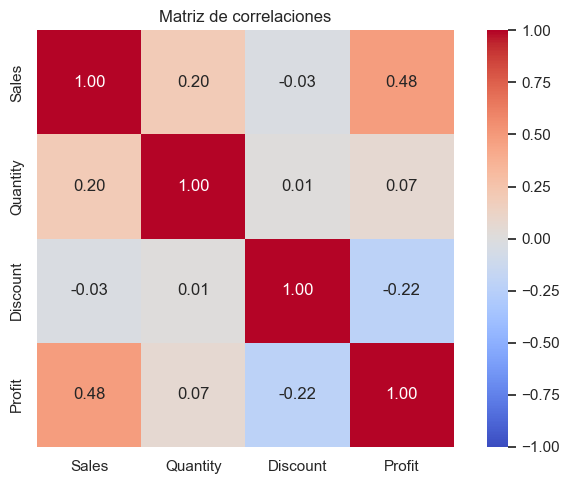

In [60]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[cols_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()


### 7.2 Matriz de correlaciones ampliada (con get_dummies)

Sobre las 4 numéricas + dummies de las categóricas con pocos niveles.

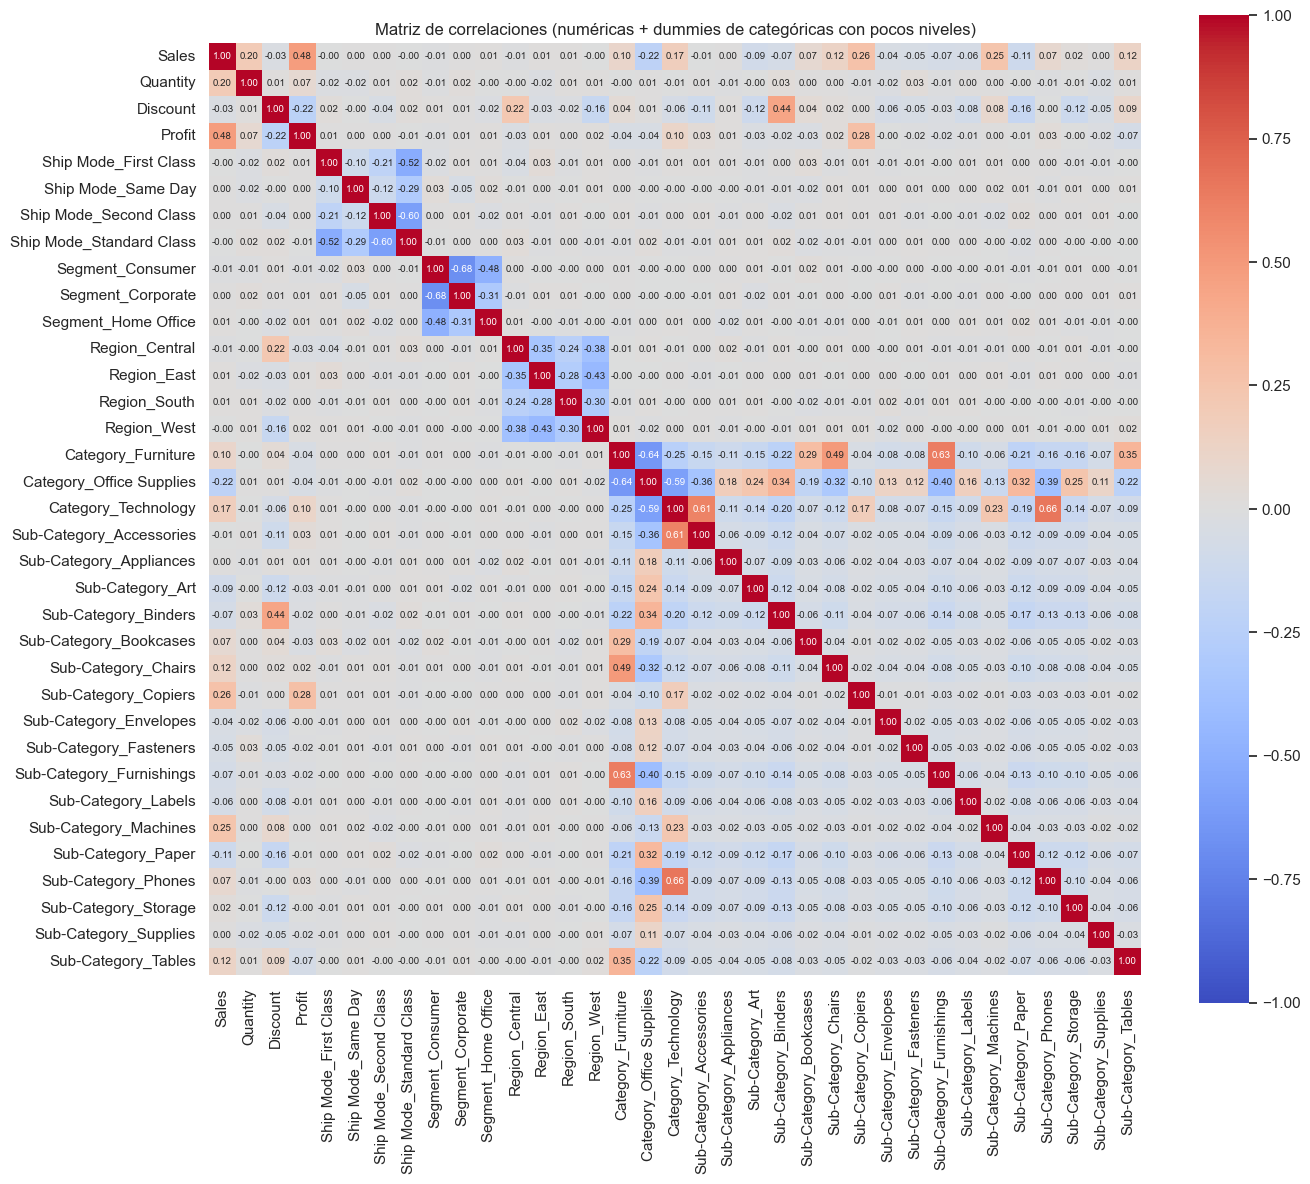

In [61]:
cat_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

df_dummies = pd.get_dummies(df[cat_cols], drop_first=False)
df_for_corr = pd.concat([df[num_cols], df_dummies], axis=1)

plt.figure(figsize=(14, 12))
sns.heatmap(
    df_for_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    annot_kws={'size': 7}
)
plt.title('Matriz de correlaciones (numéricas + dummies de categóricas con pocos niveles)')
plt.tight_layout()
plt.show()

## Limpieza final y conversión de tipos

- Eliminamos las 11 filas con Postal Code nulo (0,11 % del total).
- Convertimos Postal Code a tipo `category` (más eficiente en memoria y conceptualmente correcto).

In [62]:
df = df.dropna(subset=['Postal Code'])
df['Postal Code'] = df['Postal Code'].astype('category')

df.info()

<class 'pandas.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9983 non-null   str           
 1   Order ID       9983 non-null   str           
 2   Order Date     9983 non-null   datetime64[us]
 3   Ship Date      9983 non-null   datetime64[us]
 4   Ship Mode      9983 non-null   str           
 5   Customer ID    9983 non-null   str           
 6   Customer Name  9983 non-null   str           
 7   Segment        9983 non-null   str           
 8   Country        9983 non-null   str           
 9   City           9983 non-null   str           
 10  State          9983 non-null   str           
 11  Postal Code    9983 non-null   category      
 12  Region         9983 non-null   str           
 13  Product ID     9983 non-null   str           
 14  Category       9983 non-null   str           
 15  Sub-Category   9983 non-null   str   

## 8. Análisis de fechas y variables derivadas

Creamos métricas de negocio que no vienen explícitas en el CSV:

- **ventas_mensuales** — suma de Sales por mes.
- **ventas_anuales** — suma de Sales por año.
- **pedidos_anuales** — número de pedidos únicos (Order IDs distintos) por año. Clave: un mismo pedido puede aparecer en varias filas si tiene varios productos.
- **ticket_medio_anual** = ventas_anuales / pedidos_anuales. Cuánto gasta un cliente de media en cada compra.
- **Dias Envio** — diferencia en días entre Ship Date y Order Date.

In [63]:
ventas_mensuales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
ventas_anuales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()
pedidos_anuales = df.groupby(df['Order Date'].dt.year)['Order ID'].nunique()
ticket_medio_anual = ventas_anuales / pedidos_anuales

df['Dias Envio'] = (df['Ship Date'] - df['Order Date']).dt.days

print('VENTAS MENSUALES:')
print(ventas_mensuales)
print('\nVENTAS ANUALES:')
print(ventas_anuales)
print('\nPEDIDOS ÚNICOS ANUALES:')
print(pedidos_anuales)
print('\nTICKET MEDIO ANUAL:')
print(ticket_medio_anual.round(2))
print('\nDÍAS DE ENVÍO — estadísticas:')
print(df['Dias Envio'].describe().round(2))

VENTAS MENSUALES:
Order Date
2015-01     14236.8950
2015-02      4519.8920
2015-03     55691.0090
2015-04     28295.3450
2015-05     23648.2870
2015-06     34595.1276
2015-07     33946.3930
2015-08     27909.4685
2015-09     81777.3508
2015-10     31453.3930
2015-11     78628.7167
2015-12     69545.6205
2016-01     18174.0756
2016-02     11951.4110
2016-03     38726.2520
2016-04     34195.2085
2016-05     30131.6865
2016-06     24797.2920
2016-07     28765.3250
2016-08     36898.3322
2016-09     64595.9180
2016-10     31404.9235
2016-11     70852.4635
2016-12     74919.5212
2017-01     16870.1810
2017-02     22978.8150
2017-03     51715.8750
2017-04     37455.2890
2017-05     56987.7280
2017-06     40344.5340
2017-07     39261.9630
2017-08     31115.3743
2017-09     73410.0249
2017-10     59687.7450
2017-11     79411.9658
2017-12     96999.0430
2018-01     43334.1940
2018-02     20301.1334
2018-03     58872.3528
2018-04     36521.5361
2018-05     44261.1102
2018-06     52981.7257
2018-

## 9. Visualizaciones

Elegimos el gráfico según el tipo de variable:

- Categórica con pocos valores (≤ 20) → countplot
- Categórica con muchos valores → barplot del top N
- Numérica muy sesgada → histograma en escala log
- Temporal (fechas) → lineplot agrupado por mes/año
- Numérica cruzada con categórica → boxplot
- Dos numéricas → scatterplot

In [64]:
sns.set_theme(style='whitegrid', palette='deep')

### 9.1 Categóricas con pocos niveles → countplot

`Ship Mode` es la única categórica ordinal del grupo, así que la graficamos aparte con su orden natural (de más rápido a más lento) en lugar de ordenarla por frecuencia.

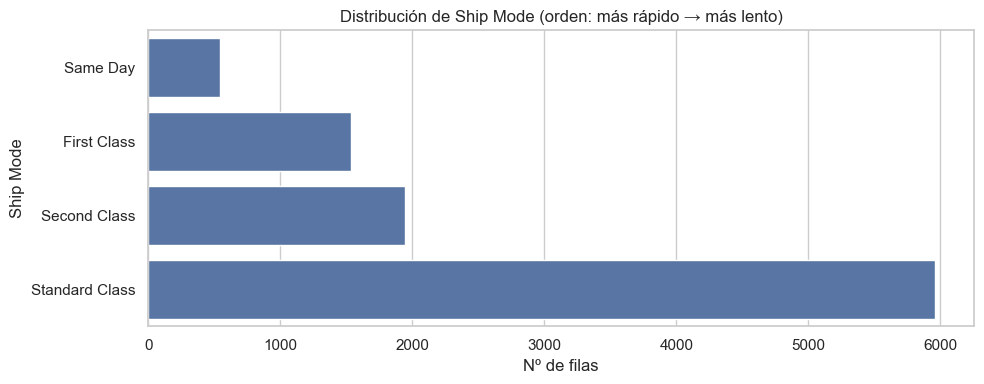

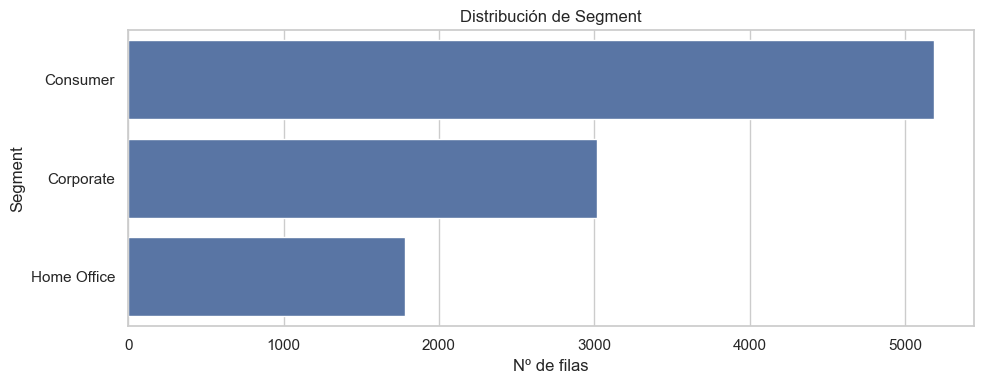

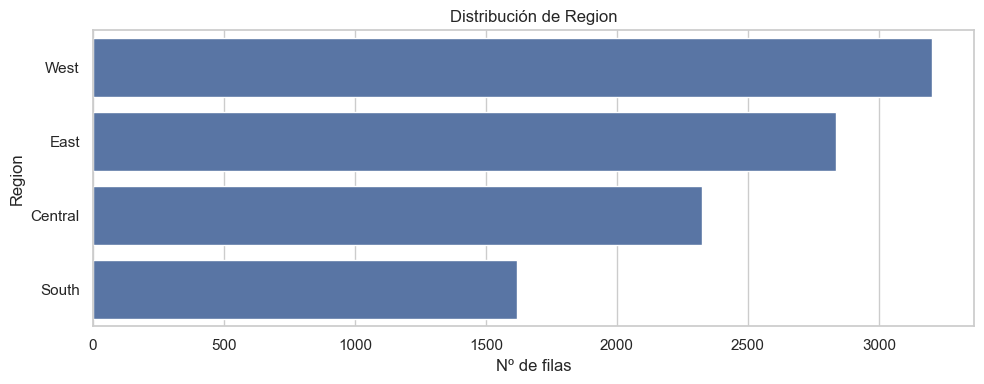

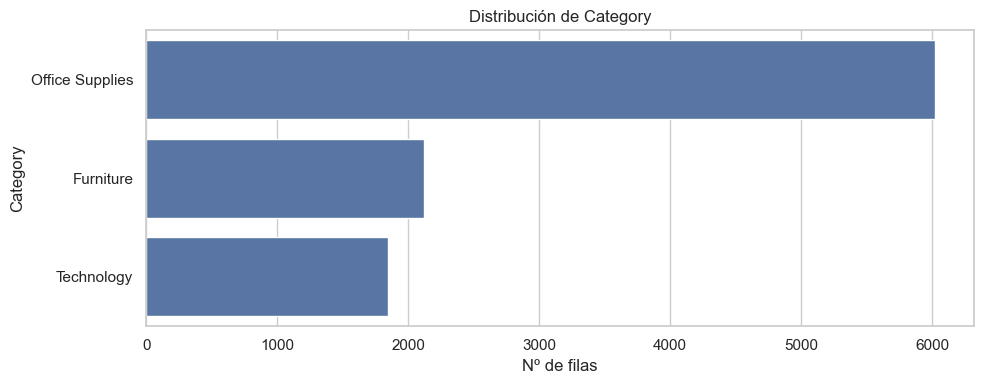

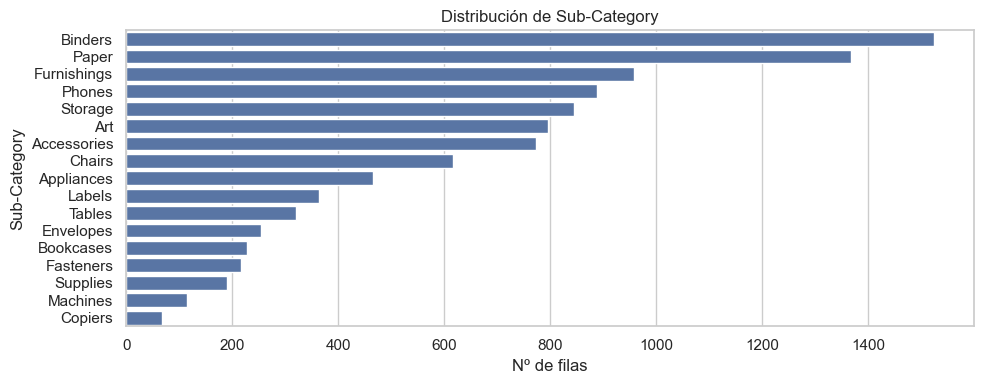

In [65]:
# Ship Mode — categórica ordinal: ordenada por velocidad de entrega
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df, y='Ship Mode',
    order=['Same Day', 'First Class', 'Second Class', 'Standard Class']
)
plt.title('Distribución de Ship Mode (orden: más rápido → más lento)')
plt.xlabel('Nº de filas')
plt.tight_layout()
plt.show()

# Resto — categóricas nominales: ordenadas por frecuencia
cat_pocas = ['Segment', 'Region', 'Category', 'Sub-Category']

for col in cat_pocas:
    plt.figure(figsize=(10, 4))
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden)
    plt.title(f'Distribución de {col}')
    plt.xlabel('Nº de filas')
    plt.tight_layout()
    plt.show()

### 9.2 Categóricas con muchos niveles → top 15

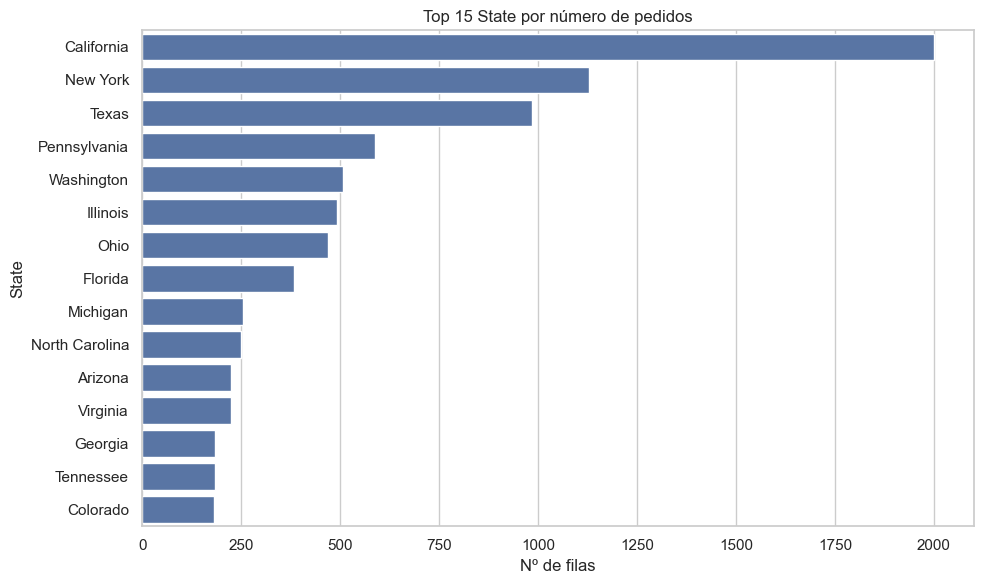

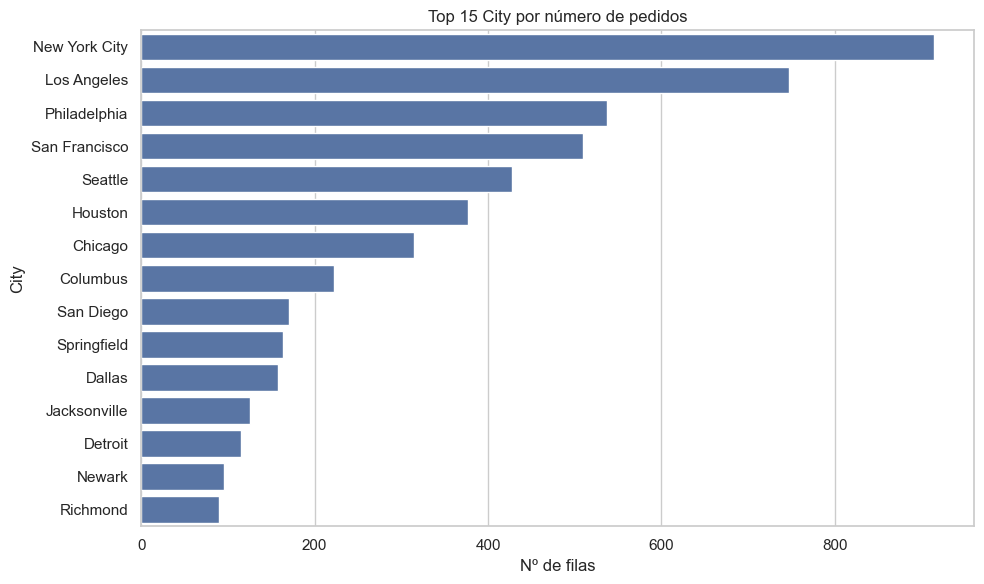

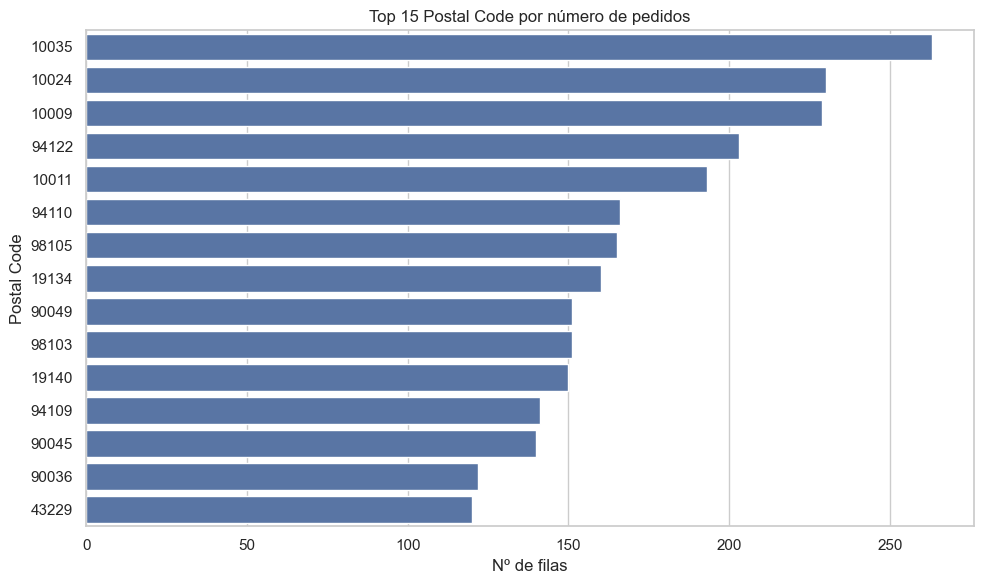

In [66]:
for col, top_n in [('State', 15), ('City', 15), ('Postal Code', 15)]:
    plt.figure(figsize=(10, 6))
    top = df[col].value_counts().head(top_n)
    sns.barplot(x=top.values, y=top.index.astype(str))
    plt.title(f'Top {top_n} {col} por número de pedidos')
    plt.xlabel('Nº de filas')
    plt.tight_layout()
    plt.show()

### 9.3 Distribución de Sales → histograma en escala log

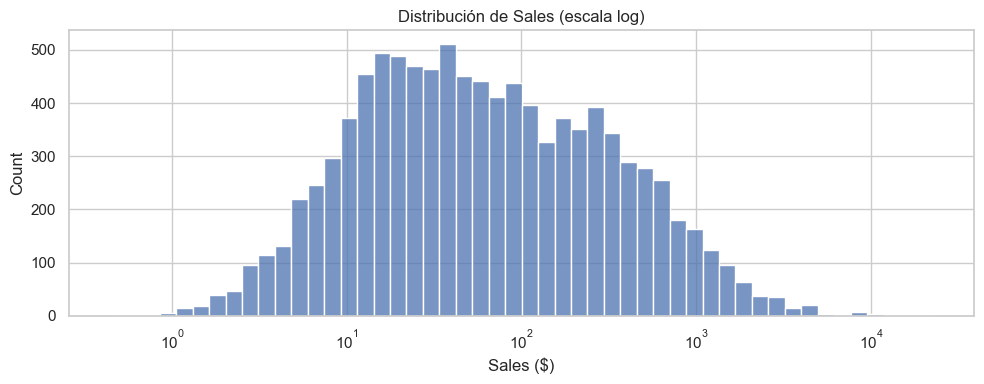

In [67]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Sales'], bins=50, log_scale=True)
plt.title('Distribución de Sales (escala log)')
plt.xlabel('Sales ($)')
plt.tight_layout()
plt.show()

### 9.4 Distribución de Quantity → countplot

Aunque Quantity es numérica continua, en la práctica toma muy pocos valores únicos en el dataset (del 1 al 14). Usamos un countplot para ver la distribución con más claridad que un histograma.

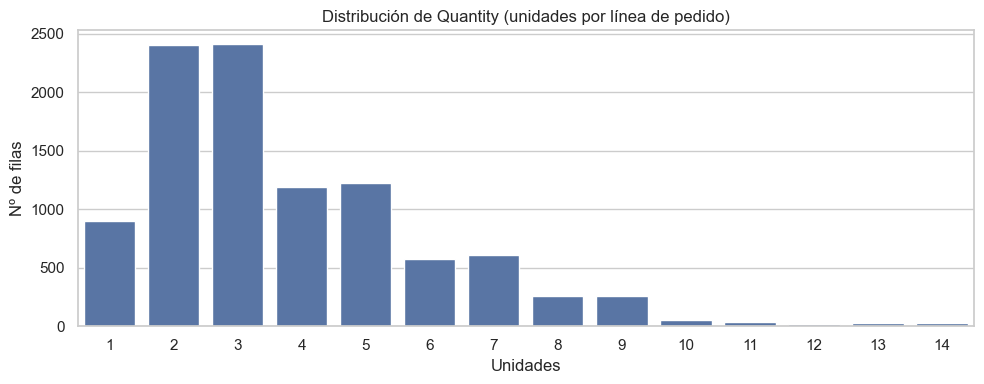

In [68]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Quantity')
plt.title('Distribución de Quantity (unidades por línea de pedido)')
plt.xlabel('Unidades')
plt.ylabel('Nº de filas')
plt.tight_layout()
plt.show()

### 9.5 Distribución de Discount → countplot

Discount es numérica discreta con solo 12 valores posibles (catálogo cerrado de descuentos). El countplot muestra cuántas ventas corresponden a cada tramo.

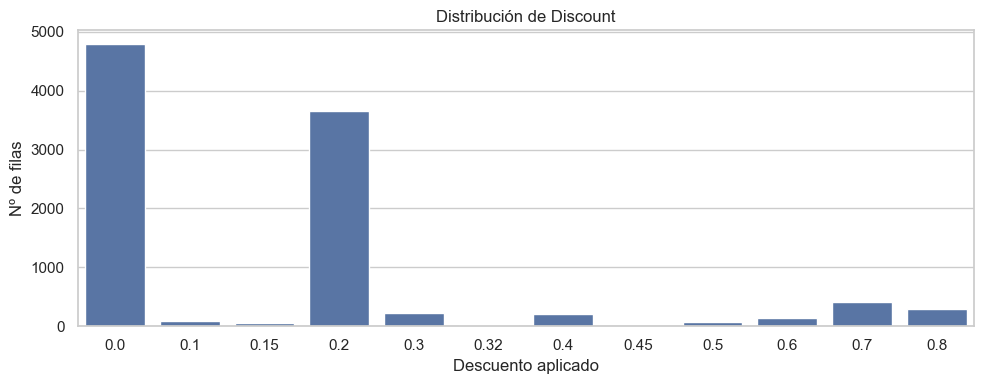

In [69]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Discount')
plt.title('Distribución de Discount')
plt.xlabel('Descuento aplicado')
plt.ylabel('Nº de filas')
plt.tight_layout()
plt.show()

### 9.6 Distribución de Profit → histograma con escala symlog

Profit tiene valores negativos (pérdidas) además de positivos, y su rango es enorme (-6.600 a +8.400). Usamos escala `symlog` que comprime los extremos pero permite valores negativos, a diferencia de la escala log pura. Calculamos los bins manualmente en escala logarítmica para que cada barra ocupe el espacio correcto en el eje (con `histplot` y bins automáticos las barras se apelotonarían cerca del 0).

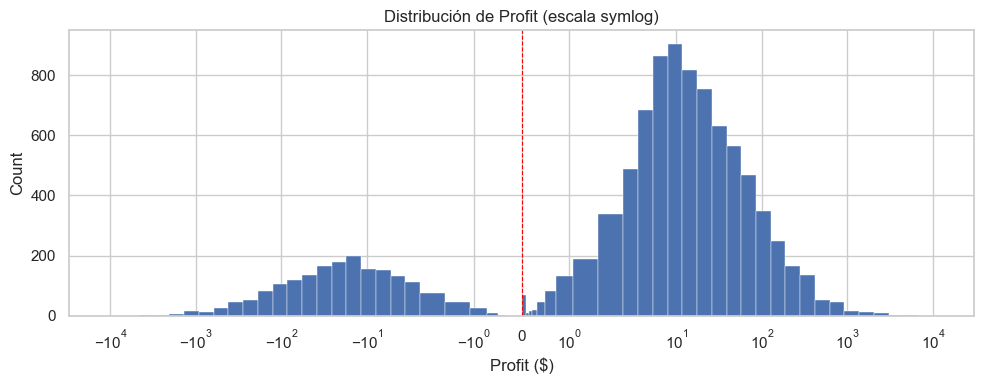

In [70]:
# Bins simétricos en escala log: cada bin ocupa una franja proporcional en el eje symlog
abs_max = max(abs(df['Profit'].min()), abs(df['Profit'].max()))
log_max = np.ceil(np.log10(abs_max))
positivos = np.logspace(-1, log_max, 30)
negativos = -positivos[::-1]
bins = np.concatenate([negativos, [0], positivos])

plt.figure(figsize=(10, 4))
plt.hist(df['Profit'], bins=bins, edgecolor='white', linewidth=0.3)
plt.xscale('symlog')
plt.axvline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('Distribución de Profit (escala symlog)')
plt.xlabel('Profit ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 9.7 Serie temporal → ventas mensuales por Order Date

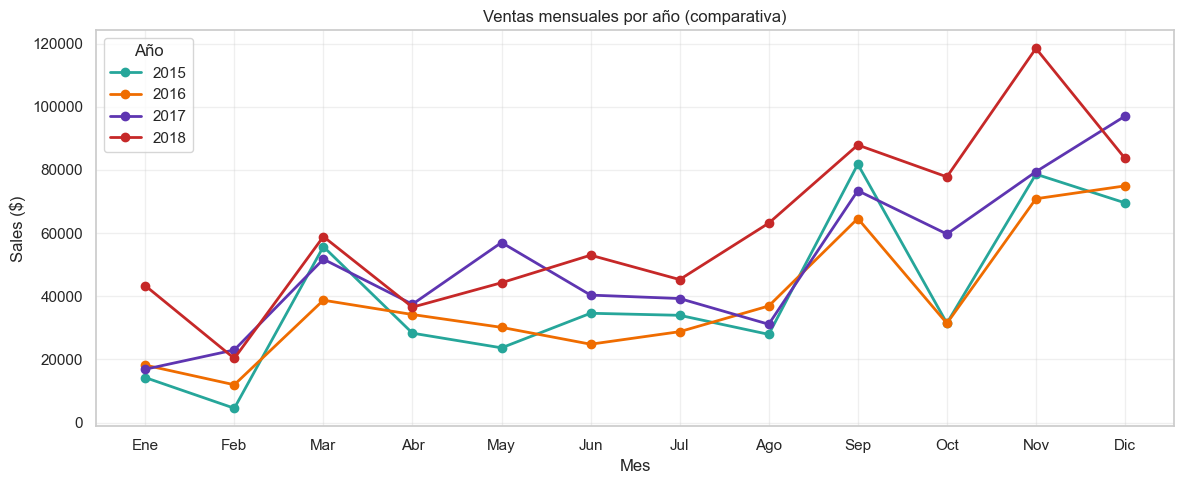

In [71]:
# Pivot: filas=mes (1-12), columnas=año, valores=Sales
ventas_por_año_mes = df.groupby(
    [df['Order Date'].dt.year, df['Order Date'].dt.month]
)['Sales'].sum().unstack(level=0)

# Colores explícitos (uno por año)
colores = ['#26a69a', '#ef6c00', '#5e35b1', '#c62828'] #          teal       naranja    morado     rojo

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ventas_por_año_mes.plot(ax=ax, marker='o', color=colores, linewidth=2)

ax.set_title('Ventas mensuales por año (comparativa)')
ax.set_xlabel('Mes')
ax.set_ylabel('Sales ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
ax.legend(title='Año')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9.8 Días de envío por modalidad → boxplot

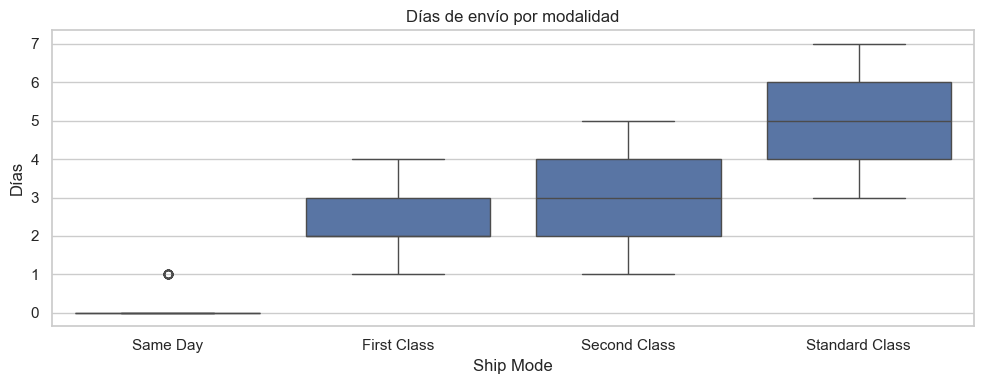

In [72]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df,
    x='Ship Mode',
    y='Dias Envio',
    order=['Same Day', 'First Class', 'Second Class', 'Standard Class']
)
plt.title('Días de envío por modalidad')
plt.ylabel('Días')
plt.tight_layout()
plt.show()

### 9.9 Distribución de Segment → pie chart

`Segment` es categórica con solo 3 valores (Consumer, Corporate, Home Office). Como nos interesa la proporción relativa de cada uno sobre el total, un pie chart funciona mejor que un countplot. Etiquetas traducidas al español para legibilidad.

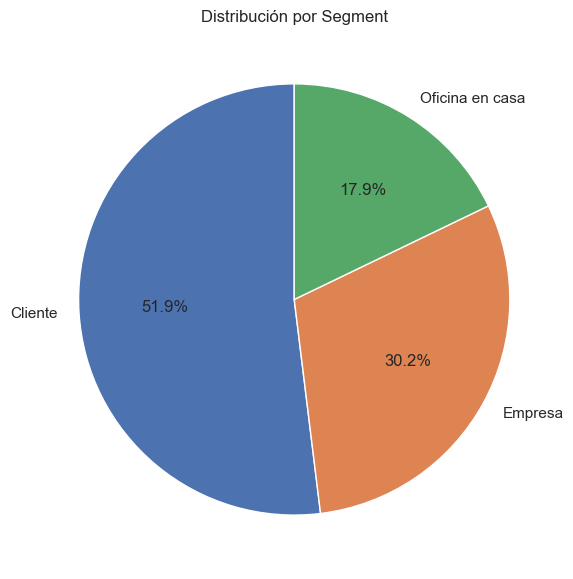

In [73]:
segment_counts = df['Segment'].value_counts()

# Etiquetas en español
nuevas_labels = ['Cliente', 'Empresa', 'Oficina en casa']

plt.figure(figsize=(6, 6))
plt.pie(
    segment_counts.values,
    labels=nuevas_labels,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribución por Segment')
plt.tight_layout()
plt.show()

## 10. Variables derivadas anuales

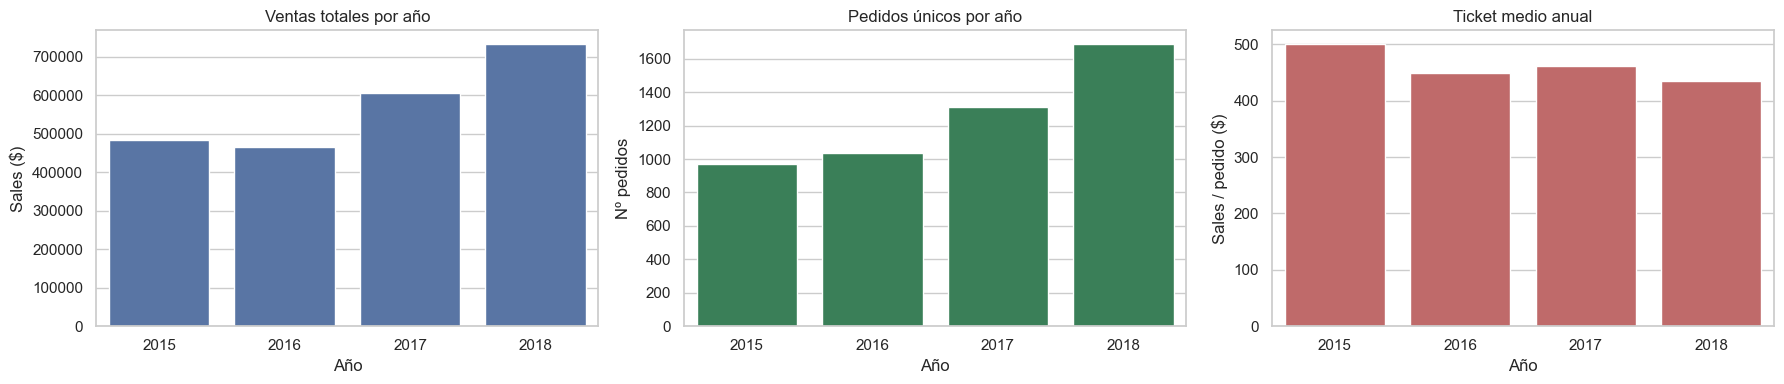

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(x=ventas_anuales.index, y=ventas_anuales.values, ax=axes[0])
axes[0].set_title('Ventas totales por año')
axes[0].set_ylabel('Sales ($)')
axes[0].set_xlabel('Año')

sns.barplot(x=pedidos_anuales.index, y=pedidos_anuales.values, ax=axes[1], color='seagreen')
axes[1].set_title('Pedidos únicos por año')
axes[1].set_ylabel('Nº pedidos')
axes[1].set_xlabel('Año')

sns.barplot(x=ticket_medio_anual.index, y=ticket_medio_anual.values, ax=axes[2], color='indianred')
axes[2].set_title('Ticket medio anual')
axes[2].set_ylabel('Sales / pedido ($)')
axes[2].set_xlabel('Año')

plt.tight_layout()
plt.show()

## 11. Productos: precio vs volumen

### 11.1 Top 15 productos con mayor precio medio de venta

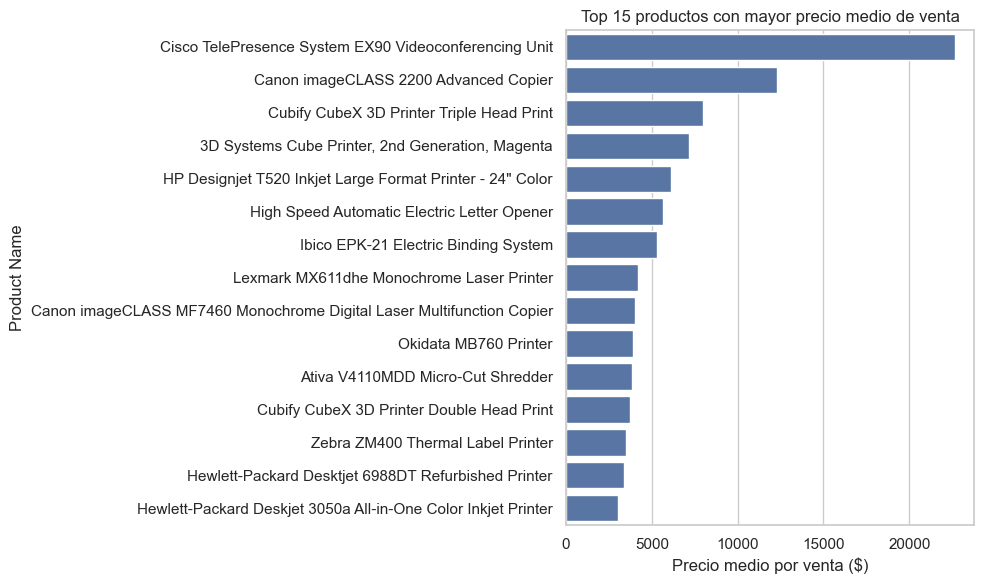

In [75]:
precio_medio = df.groupby('Product Name')['Sales'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=precio_medio.values, y=precio_medio.index)
plt.title('Top 15 productos con mayor precio medio de venta')
plt.xlabel('Precio medio por venta ($)')
plt.tight_layout()
plt.show()

### 11.2 Top 15 productos por ingresos totales

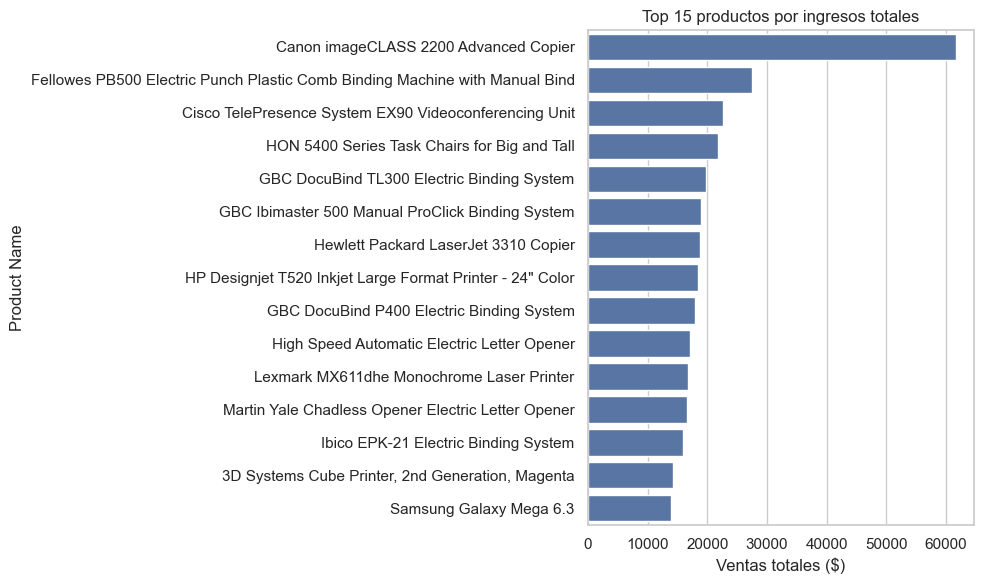

In [76]:
ingresos = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=ingresos.values, y=ingresos.index)
plt.title('Top 15 productos por ingresos totales')
plt.xlabel('Ventas totales ($)')
plt.tight_layout()
plt.show()

### 11.3 Precio medio por Sub-Category

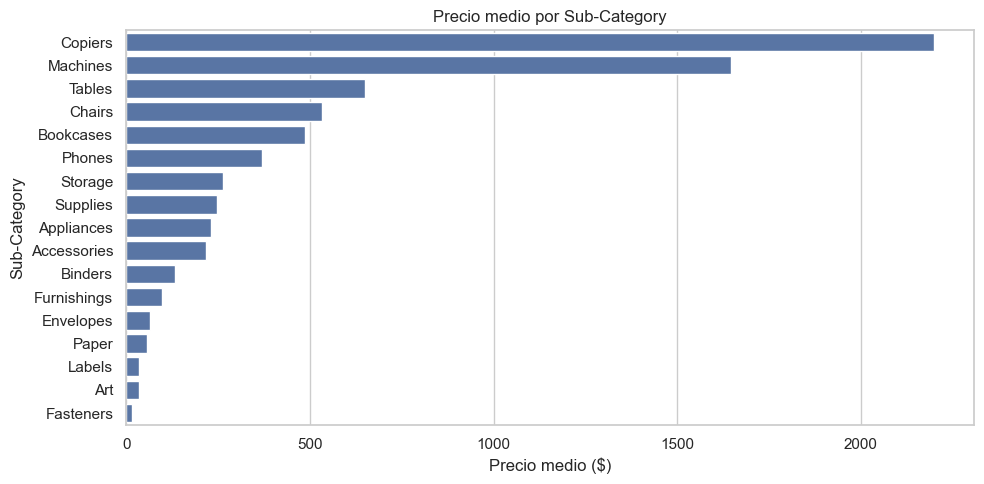

In [77]:
precio_por_subcat = df.groupby('Sub-Category')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=precio_por_subcat.values, y=precio_por_subcat.index)
plt.title('Precio medio por Sub-Category')
plt.xlabel('Precio medio ($)')
plt.tight_layout()
plt.show()

### 11.4 Scatterplot: volumen vs precio medio por Sub-Category

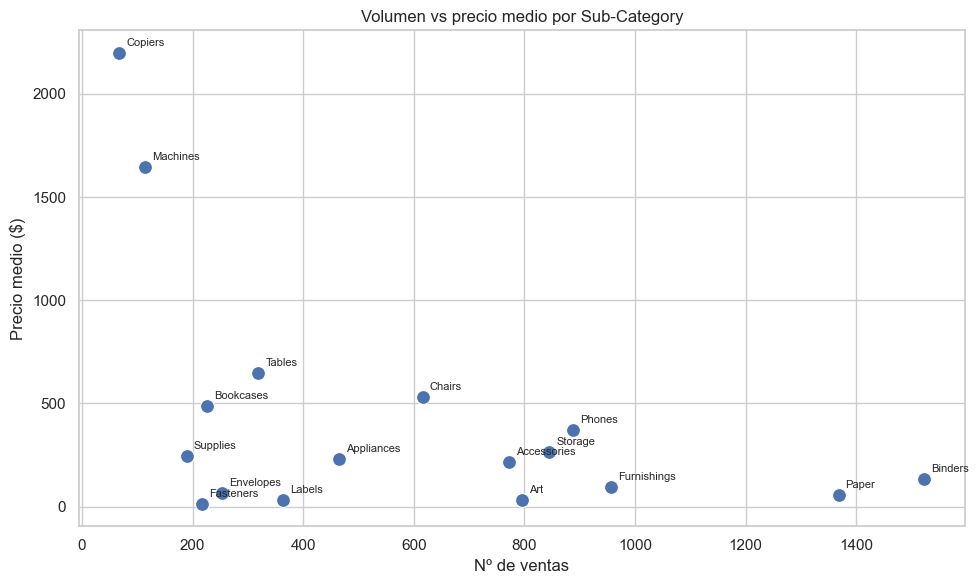

In [78]:
resumen = df.groupby('Sub-Category').agg(
    precio_medio=('Sales', 'mean'),
    n_ventas=('Sales', 'count')
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=resumen, x='n_ventas', y='precio_medio', s=100)

for _, row in resumen.iterrows():
    plt.annotate(
        row['Sub-Category'],
        (row['n_ventas'], row['precio_medio']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.title('Volumen vs precio medio por Sub-Category')
plt.xlabel('Nº de ventas')
plt.ylabel('Precio medio ($)')
plt.tight_layout()
plt.show()

## 12. Análisis de rentabilidad

Usamos las columnas `Quantity`, `Discount` y `Profit` para responder preguntas que solo con `Sales` no se pueden contestar: qué productos dan dinero de verdad, qué descuentos son asumibles y cuáles destruyen el margen.

### 12.1 Profit total por Sub-Category

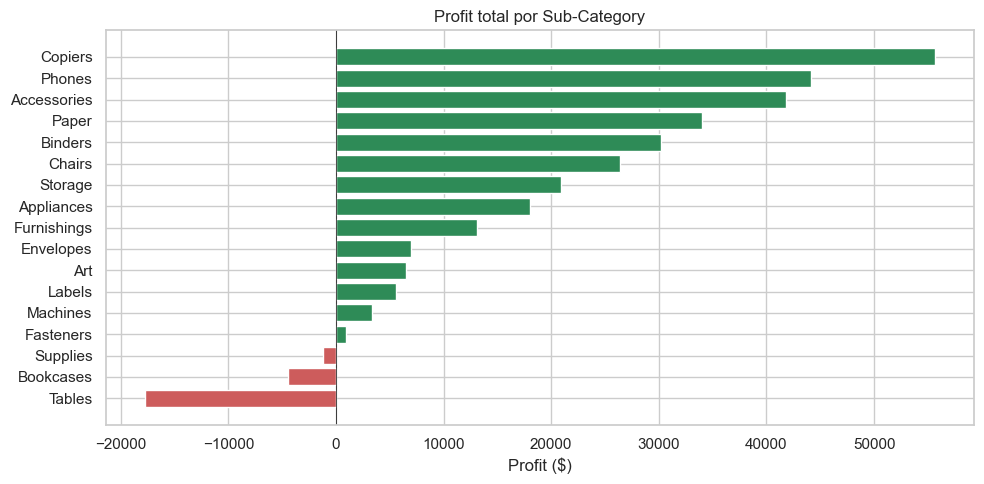

In [79]:
profit_subcat = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in profit_subcat.values]
plt.barh(profit_subcat.index, profit_subcat.values, color=colors)
plt.gca().invert_yaxis()
plt.title('Profit total por Sub-Category')
plt.xlabel('Profit ($)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 12.2 Facturación vs rentabilidad por Sub-Category

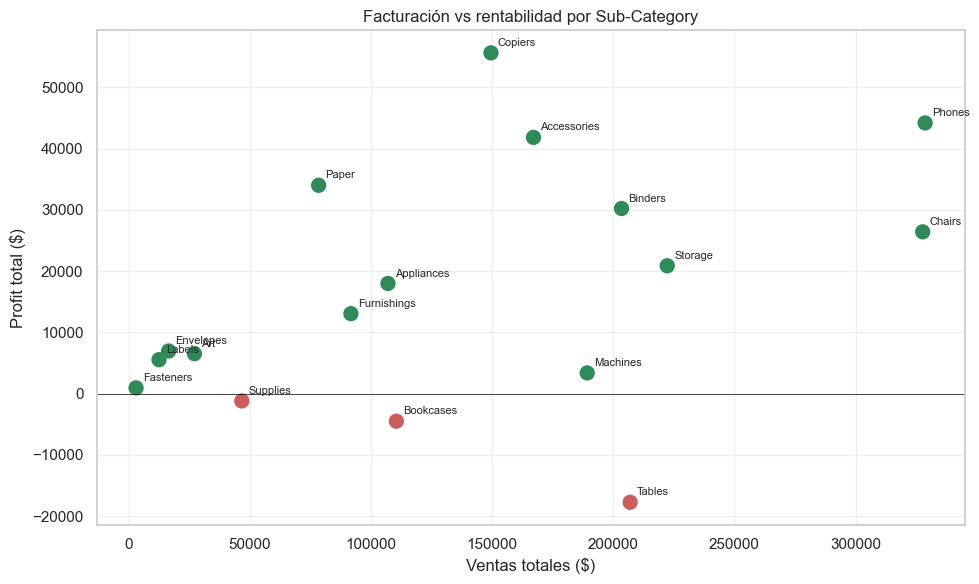

In [80]:
resumen_rent = df.groupby('Sub-Category').agg(
    sales=('Sales', 'sum'),
    profit=('Profit', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
colors = ['seagreen' if p > 0 else 'indianred' for p in resumen_rent['profit']]
plt.scatter(resumen_rent['sales'], resumen_rent['profit'], s=100, c=colors)

for _, row in resumen_rent.iterrows():
    plt.annotate(
        row['Sub-Category'],
        (row['sales'], row['profit']),
        fontsize=8,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.axhline(0, color='black', linewidth=0.5)
plt.title('Facturación vs rentabilidad por Sub-Category')
plt.xlabel('Ventas totales ($)')
plt.ylabel('Profit total ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.3 Relación descuento vs rentabilidad

                   mean        sum  count
Tramo Descuento                          
0%                66.59  318742.62   4787
1-10%             96.06    9029.18     94
10-20%            24.74   91756.30   3709
20-30%           -45.68  -10369.28    227
30-50%          -156.28  -48447.73    310
50-80%           -89.44  -76559.05    856


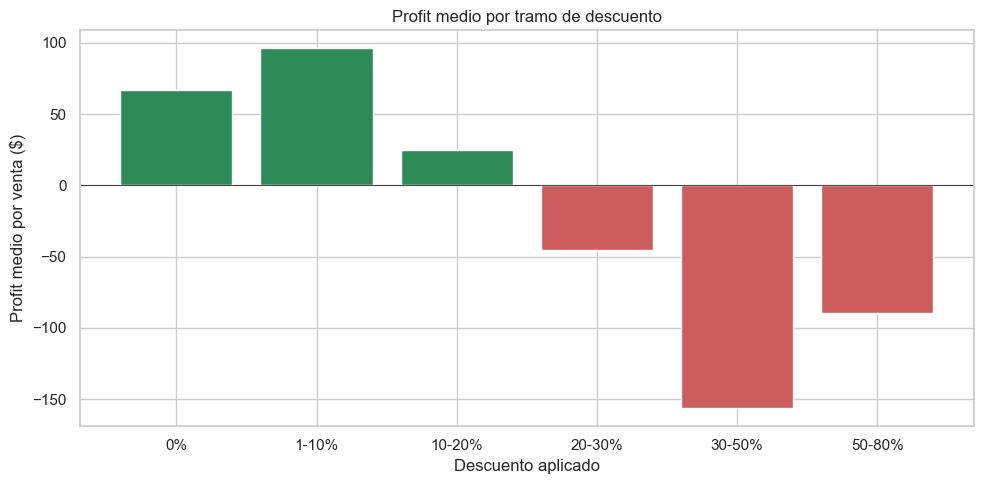

In [81]:
# Agrupamos por tramos de descuento y vemos el profit medio en cada tramo
bins = [-0.01, 0.01, 0.1, 0.2, 0.3, 0.5, 0.8]
labels = ['0%', '1-10%', '10-20%', '20-30%', '30-50%', '50-80%']
df['Tramo Descuento'] = pd.cut(df['Discount'], bins=bins, labels=labels)

profit_por_descuento = df.groupby('Tramo Descuento', observed=True)['Profit'].agg(['mean', 'sum', 'count'])
print(profit_por_descuento.round(2))

plt.figure(figsize=(10, 5))
colors = ['seagreen' if v > 0 else 'indianred' for v in profit_por_descuento['mean']]
plt.bar(profit_por_descuento.index.astype(str), profit_por_descuento['mean'], color=colors)
plt.title('Profit medio por tramo de descuento')
plt.ylabel('Profit medio por venta ($)')
plt.xlabel('Descuento aplicado')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### 12.4 Top 10 productos más rentables y menos rentables

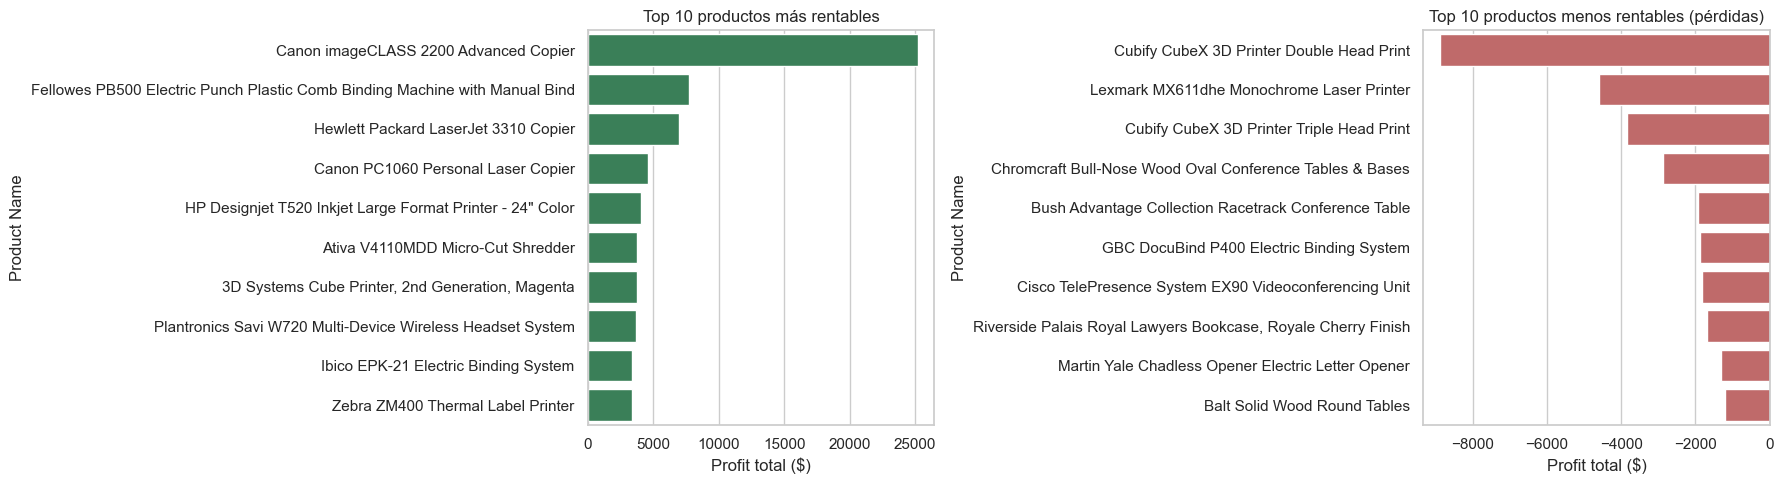

In [82]:
profit_producto = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

top_10 = profit_producto.head(10)
bottom_10 = profit_producto.tail(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.barplot(x=top_10.values, y=top_10.index, ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 productos más rentables')
axes[0].set_xlabel('Profit total ($)')

sns.barplot(x=bottom_10.values, y=bottom_10.index, ax=axes[1], color='indianred')
axes[1].set_title('Top 10 productos menos rentables (pérdidas)')
axes[1].set_xlabel('Profit total ($)')

plt.tight_layout()
plt.show()

### 12.5 Distribución del margen porcentual por nivel de descuento → boxplot

En vez de graficar `Profit` absoluto (en dólares), usamos el **margen porcentual** (`Profit / Sales × 100`). Razón: un descuento alto puede generar una pérdida pequeña en dólares si el producto es barato, y eso distorsiona la lectura visual del `Profit` absoluto. El margen porcentual normaliza todas las ventas a una escala común — lo que importa no es cuánto se pierde en euros, sino qué fracción del precio de venta se destruye.

Con margen porcentual, el descenso es monótono: a más descuento, más destrucción de valor relativo. No hay trampa visual.

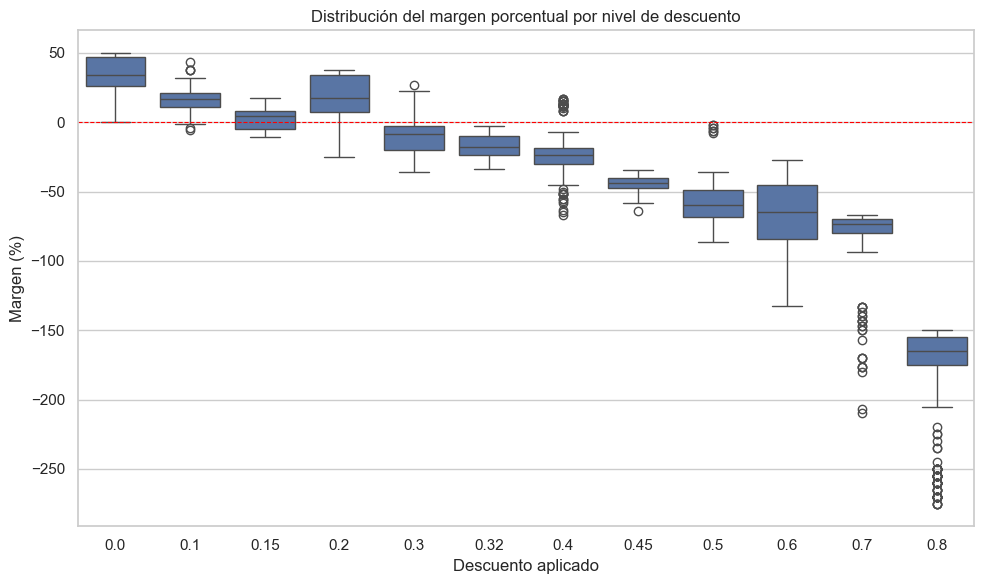

In [83]:
# Calculamos margen porcentual por línea de venta
df['Margen'] = df['Profit'] / df['Sales'] * 100

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Discount', y='Margen')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.title('Distribución del margen porcentual por nivel de descuento')
plt.xlabel('Descuento aplicado')
plt.ylabel('Margen (%)')
plt.tight_layout()
plt.show()

## 13. Relplot — relación entre Descuento y Ventas

Se ve cómo hay pedidos grandes sin oferta y pedidos muy grandes con mucha oferta. El descuento parece usarse como herramienta puntual: a veces se descuenta mucho para pedidos grandes, pero otras veces se consiguen ventas grandes sin tocar el precio.

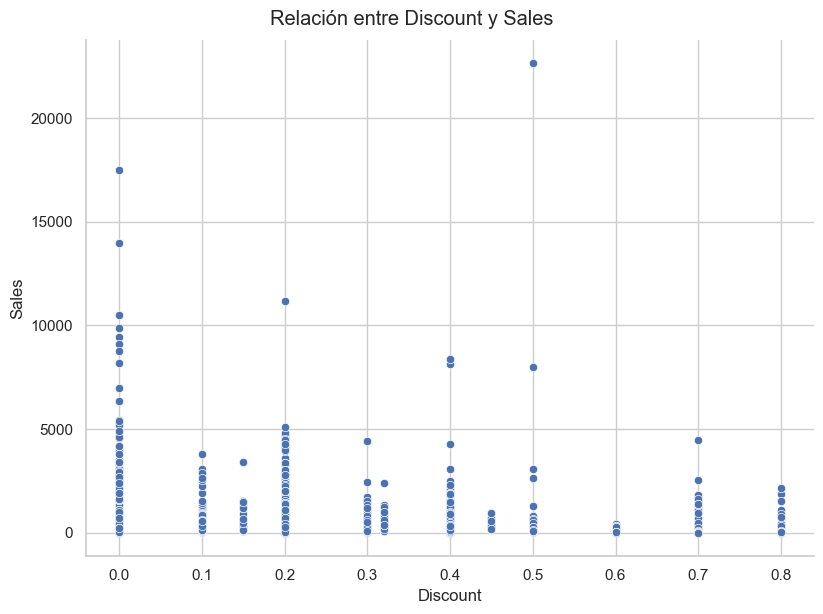

In [84]:
x_col = 'Discount'   # descuento
y_col = 'Sales'      # ventas

g = sns.relplot(
    data=df,
    x=x_col,
    y=y_col,
    kind='scatter',
    height=6,
    aspect=1.4
)

g.fig.suptitle(f'Relación entre {x_col} y {y_col}', y=1.02)
plt.show()

# Lectura:
# - Eje X: descuento aplicado (numérico)
# - Eje Y: ventas (importe en $)
# - Cada punto: una línea de pedido

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

print("Cargamos y dividimos los datos")


Cargamos y dividimos los datos


In [86]:
df['año']  = df['Order Date'].dt.year
df['mes'] = df['Order Date'].dt.month
columnas = [ 'Order ID', 'Ship Mode',
            'Customer Name', 'Segment','City',
            'State', 'Postal Code', 'Region', 'Product ID', 'Category',
            'Sub-Category', 'Product Name', 'Quantity', 'Discount', 'Profit', 'año','mes']

num_cols = ['Quantity', 'Discount', 'Profit',"año","mes"]
cat_cols = ['Order ID', 'Ship Mode','Customer Name', 'Segment','City','State', 'Postal Code', 'Region', 'Product ID', 'Category','Sub-Category', 'Product Name',]

X = df[columnas]
y = df['Sales']
df.info()

<class 'pandas.DataFrame'>
Index: 9983 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Row ID           9983 non-null   str           
 1   Order ID         9983 non-null   str           
 2   Order Date       9983 non-null   datetime64[us]
 3   Ship Date        9983 non-null   datetime64[us]
 4   Ship Mode        9983 non-null   str           
 5   Customer ID      9983 non-null   str           
 6   Customer Name    9983 non-null   str           
 7   Segment          9983 non-null   str           
 8   Country          9983 non-null   str           
 9   City             9983 non-null   str           
 10  State            9983 non-null   str           
 11  Postal Code      9983 non-null   category      
 12  Region           9983 non-null   str           
 13  Product ID       9983 non-null   str           
 14  Category         9983 non-null   str           
 15  Sub

In [87]:
pipe_num = Pipeline([
    ('scaler', StandardScaler()),
])

In [88]:
pipe_cat = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

In [89]:
preprocessor = ColumnTransformer([
    ('num', pipe_num, num_cols),
    ('cat', pipe_cat, cat_cols),
])

In [90]:

pipe_randomf = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=17, random_state=42)),
    ('regresor', RandomForestRegressor(random_state=42))
])

In [91]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=17, random_state=42)),
    ('regresor', LinearRegression())
])

In [92]:
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=17, random_state=42)),
    ('regresor', XGBRegressor(random_state=42, n_estimators=100, n_jobs=-1))
])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe_randomf.fit(X_train, y_train)
pipe_lr.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)


In [ ]:
# Varianza capturada por PCA (es la misma en los 3, mismo preprocesador)
pca = pipe_randomf.named_steps['pca']
print(f"Componentes PCA: {pca.n_components_}")
print(f"Varianza capturada: {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

# Comparativa de modelos
print(f"{'Modelo':<15} {'R² train':>10} {'R² test':>10}")
print("-" * 38)
for nombre, pipe in [('RandomForest', pipe_randomf),
                     ('LinearReg', pipe_lr),
                     ('XGBoost', pipe_xgb)]:
    r2_tr = pipe.score(X_train, y_train)
    r2_te = pipe.score(X_test, y_test)
    print(f"{nombre:<15} {r2_tr:>10.4f} {r2_te:>10.4f}")

Componentes PCA: 17
Varianza capturada: 55.15%

Modelo            R² train    R² test
--------------------------------------
RandomForest        0.9505     0.7733
LinearReg           0.2944     0.3140
XGBoost             0.9907     0.7823


In [ ]:
# (Esta celda re-entrenaba los modelos otra vez — eliminada por redundante.
#  Los pipelines ya están entrenados arriba.)


## 14. GridSearchCV con los 3 modelos y 3 métricas

Optimización de hiperparámetros con validación cruzada (k=5) para los tres pipelines.

- **R²**: % de varianza explicada (adimensional, comparable entre modelos).
- **MAE**: error medio absoluto en dólares (robusto a outliers).
- **RMSE**: raíz del error cuadrático medio en dólares (penaliza más los errores grandes).

`refit='r2'` → el grid elige el mejor modelo por R², pero reporta las tres métricas.


In [ ]:
# R² de los 3 modelos antes del GridSearch (entrenados con hiperparámetros por defecto)
print(f"R² test — RandomForest : {pipe_randomf.score(X_test, y_test):.4f}")
print(f"R² test — LinearReg    : {pipe_lr.score(X_test, y_test):.4f}")
print(f"R² test — XGBoost      : {pipe_xgb.score(X_test, y_test):.4f}")


R² test — RandomForest : 0.7733
R² test — LinearReg    : 0.3140
R² test — XGBoost      : 0.7823


In [ ]:
# GridSearch con TRES métricas: R², MAE, MSE

from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

configs = {
    'RandomForest': (pipe_randomf, {
        'regresor__n_estimators': [50, 100],
        'regresor__max_depth': [5, None],
    }),
    'XGBoost': (pipe_xgb, {
        'regresor__n_estimators': [50, 100],
        'regresor__max_depth': [3, 6],
        'regresor__learning_rate': [0.1, 0.3],
    }),
    'LinearReg': (pipe_lr, {
        'regresor__fit_intercept': [True, False],
    }),
}

scoring = {
    'r2':  'r2',
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
}

resultados_finales = {}

for nombre, (pipe, grid) in configs.items():
    print(f"\n{'='*60}\n  {nombre}\n{'='*60}")

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        cv=5,
        scoring=scoring,
        refit='r2',
        return_train_score=True,
        n_jobs=-1,
    )
    gs.fit(X_train, y_train)

    i = gs.best_index_
    cv_r2  = gs.cv_results_['mean_test_r2'][i]
    cv_mae = -gs.cv_results_['mean_test_mae'][i]
    cv_mse = -gs.cv_results_['mean_test_mse'][i]

    pred = gs.best_estimator_.predict(X_test)
    test_r2  = gs.score(X_test, y_test)
    test_mae = mean_absolute_error(y_test, pred)
    test_mse = mean_squared_error(y_test, pred)

    print(f"Mejores parámetros: {gs.best_params_}")
    print(f"\n--- CV ---")
    print(f"  R²  : {cv_r2:.4f}")
    print(f"  MAE : {cv_mae:.2f} $")
    print(f"  MSE : {cv_mse:.2f} $²")
    print(f"--- Test ---")
    print(f"  R²  : {test_r2:.4f}")
    print(f"  MAE : {test_mae:.2f} $")
    print(f"  MSE : {test_mse:.2f} $²")

    resultados_finales[nombre] = {
        'cv_r2': cv_r2, 'cv_mae': cv_mae, 'cv_mse': cv_mse,
        'test_r2': test_r2, 'test_mae': test_mae, 'test_mse': test_mse,
    }

print(f"\n{'='*60}\n  COMPARATIVA FINAL\n{'='*60}")
df_resultados = pd.DataFrame(resultados_finales).T
print(df_resultados.round(2))


  RandomForest
Mejores parámetros: {'regresor__max_depth': None, 'regresor__n_estimators': 100}

--- CV ---
  R²  : 0.5614
  MAE : 123.38 $
  MSE : 182785.72 $²
--- Test ---
  R²  : 0.7733
  MAE : 118.77 $
  MSE : 89178.55 $²

  XGBoost
Mejores parámetros: {'regresor__learning_rate': 0.1, 'regresor__max_depth': 3, 'regresor__n_estimators': 100}

--- CV ---
  R²  : 0.5564
  MAE : 135.22 $
  MSE : 178146.67 $²
--- Test ---
  R²  : 0.7630
  MAE : 127.49 $
  MSE : 93229.39 $²

  LinearReg
Mejores parámetros: {'regresor__fit_intercept': True}

--- CV ---
  R²  : 0.3075
  MAE : 208.02 $
  MSE : 282460.58 $²
--- Test ---
  R²  : 0.3140
  MAE : 211.50 $
  MSE : 269813.74 $²

  COMPARATIVA FINAL
              cv_r2  cv_mae     cv_mse  test_r2  test_mae   test_mse
RandomForest   0.56  123.38  182785.72     0.77    118.77   89178.55
XGBoost        0.56  135.22  178146.67     0.76    127.49   93229.39
LinearReg      0.31  208.02  282460.58     0.31    211.50  269813.74


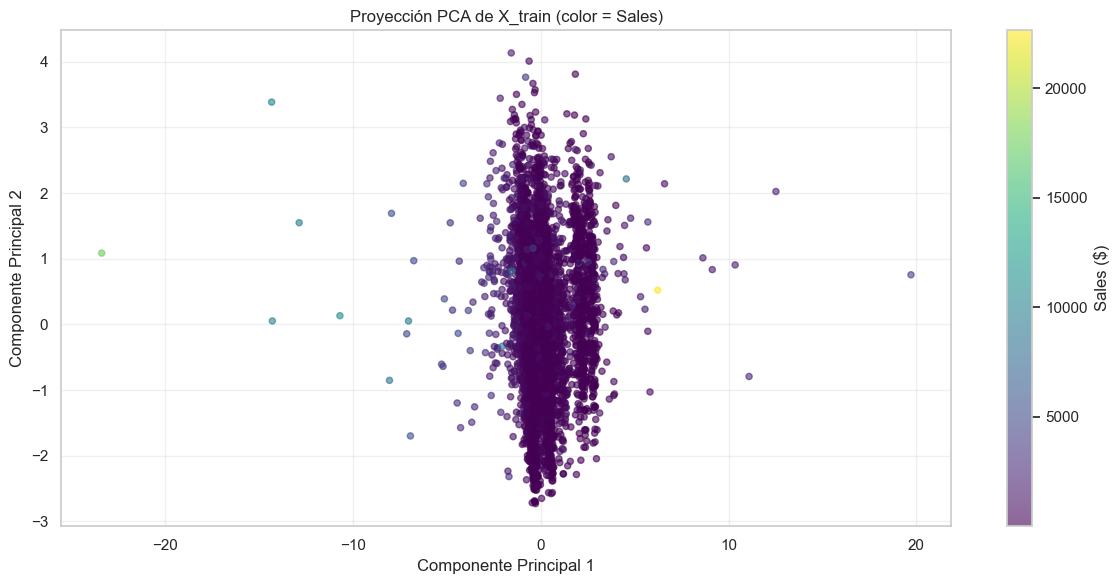

In [ ]:
# Proyección PCA real: aplicamos preprocesador + PCA a X_train y nos quedamos
# con las 2 primeras componentes para visualizar.
preproc_fit = pipe_randomf.named_steps['preprocessor']
pca_fit = pipe_randomf.named_steps['pca']

X_train_pca = pca_fit.transform(preproc_fit.transform(X_train))

plt.figure(figsize=(12, 6))
sc = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap='viridis',
    alpha=0.6,
    s=20,
)
plt.colorbar(sc, label='Sales ($)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Proyección PCA de X_train (color = Sales)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### CONCLUSIONES ###

## Resumen rápido

- Limpiamos el CSV original (10 800 filas) y, tras eliminar registros que no necesitamos, nos quedamos con 9 983 filas de ventas entre 2015 y 2018 (osea,cuatro años).
- Métricas clave: Sales, Quantity, Discount y Profit; Discount tiene pocos valores discretos y Profit muestra también pérdidas importantes.

## Hallazgos principales

### Calidad de datos

- Tras filtrar las filas finales no relacionadas quedan solo 11 filas con Postal Code nulo, que eliminamos; todo lo demás está limpio y listo para análisis.

### Ventas y estacionalidad

- Hay picos recurrentes en segunda mitad del año, y  la cola de ventas es larga con pocos pedidos muy grandes.

### Márgenes

- Profit varía mucho y hay sub-categorías y productos con pérdidas claras porque los descuentos altos suelen destruir margen.

### Descuentos

- Tramos ≥30% suelen llevar a margen negativo de media por lo que conviene controlar esas promociones.

### Logística

- Ship Mode contiene la información de los días de envío y hay cuatro modos: Same Day, First Class, Second Class y Standard Class.
- Same Day se envía en el mismo día; First Class tarda entre 2 y 3 días; Second Class entre 2 y 4 días; Standard Class entre 4 y 7 días.

### Productos

- Los que más facturan no siempre son los más rentables, lo que nos da oportunidades para ajustar surtido o precios.


## Detalles prácticos y siguientes pasos

### Política de descuentos

- Bloquear o revisar descuentos automáticos superiores al 30 % salvo excepciones justificadas.
- Usar el margen porcentual (Profit/Sales × 100) como KPI principal para evaluar promociones.

### Revisar Sub-categorías deficitarias

- Identificar sub-categorías y productos con pérdidas recurrentes.
- Negociar costes, ajustar precios o retirar productos que pierden dinero de forma sistemática.

### Promocionar lo rentable

- Localizar sub-categorías con alto margen.
- Lanzar campañas para aumentar su volumen manteniendo la rentabilidad.

### Logística

- Investigar envíos con Días Envío muy altos.
- Optimizar el mix de Ship Mode para equilibrar coste y nivel de servicio.

### Segmentación

- Mirar el ticket medio y margen por segmento (Consumer, Corporate, Home Office).
- Adaptar ofertas y promociones según la rentabilidad de cada segmento.


## Métricas y dashboards recomendados

### KPIs recomendados

- Margen % por sub-categoría.
- Profit total por sub-categoría.
- % de pedidos con margen negativo.
- Ticket medio por segmento.

### Dashboards útiles

- Ventas mensuales por año.
- Facturación vs rentabilidad por Sub-Category.
- Profit medio por tramo de descuento.
- Top States/City por número de pedidos.
      

## 15. Preview de la app Gradio en local

App Gradio con 5 inputs (City, Segment, Category, año, mes) que compara
los **3 modelos entrenados** (Random Forest, Linear Regression, XGBoost)
prediciendo sobre la misma fila de entrada.

### ML puro, sin trucos post-hoc

Cada modelo se evalúa en su régimen natural — sin aplicarle ningún ajuste
externo. Esto deja ver una propiedad estructural conocida en ML:

- **Random Forest y XGBoost** son ensembles de árboles. Los árboles aprenden
  splits dentro del rango entrenado (2015-2018). Para años > 2018 caen siempre
  en la misma hoja extrema → **predicción plana, idéntica para 2019, 2025 o 2028**.
  No extrapolan tendencia temporal.
- **Linear Regression** ajusta una función lineal sobre las componentes PCA.
  Para años > 2018 sigue la pendiente aprendida → **predicción que varía
  linealmente con el año**. Extrapola.

En consecuencia, el único modelo que hace **ML puro y predicción a futuro real**
en esta configuración es **Linear Regression**. RF y XGBoost siguen siendo
útiles para estimación condicional dentro del rango entrenado, pero no para
forecasting.

Trade-off honesto: LR suele tener R² peor que RF y XGBoost en datasets con
relaciones no lineales como este. Lo defendemos porque es el único que cumple
el objetivo "predicción a futuro" sin trucos. Si quisiéramos forecasting más
fiable, habría que usar un modelo temporal específico (Prophet, ARIMA).

### Resto de columnas

El pipeline espera 17 columnas (incluyendo `Profit`). Lo no expuesto en la UI
se rellena así:

- **State, Postal Code, Region** se infieren de City (lookup).
- **Sub-Category, Product ID, Product Name** se infieren de Category (lookup).
- **Quantity, Discount, Profit, Order ID, Customer Name, Ship Mode** usan
  mediana o moda global del dataset.

No se escribe nada a disco.


In [ ]:
# Lookups, defaults y métricas de los 3 modelos (sin ajuste CAGR)
from sklearn.metrics import r2_score, mean_absolute_error

# Lookup City -> geografía
city_lookup = {}
for city, sub in df.groupby('City'):
    city_lookup[city] = {
        'State':       sub['State'].mode()[0],
        'Postal Code': str(sub['Postal Code'].mode()[0]),
        'Region':      sub['Region'].mode()[0],
    }

# Lookup Category -> producto representativo
category_lookup = {}
for cat, sub in df.groupby('Category'):
    category_lookup[cat] = {
        'Sub-Category': sub['Sub-Category'].mode()[0],
        'Product ID':   sub['Product ID'].mode()[0],
        'Product Name': sub['Product Name'].mode()[0],
    }

# Defaults globales (Profit incluido)
defaults = {
    'Quantity':      int(df['Quantity'].median()),
    'Discount':      float(df['Discount'].median()),
    'Profit':        float(df['Profit'].median()),
    'Order ID':      df['Order ID'].mode()[0],
    'Ship Mode':     df['Ship Mode'].mode()[0],
    'Customer Name': df['Customer Name'].mode()[0],
}

# Los 3 modelos entrenados, en un dict
modelos = {
    'Random Forest':     pipe_randomf,
    'Linear Regression': pipe_lr,
    'XGBoost':           pipe_xgb,
}

# Cuáles extrapolan tendencia (importante para la UI)
extrapola_tendencia = {
    'Random Forest':     False,   # tree-based → plano fuera del rango
    'Linear Regression': True,    # función lineal → extrapola
    'XGBoost':           False,   # tree-based → plano fuera del rango
}

# Métricas de cada modelo en test
metricas_modelos = {}
for nombre, pipe in modelos.items():
    preds = pipe.predict(X_test)
    metricas_modelos[nombre] = {
        'R2':  float(r2_score(y_test, preds)),
        'MAE': float(mean_absolute_error(y_test, preds)),
    }

# Valores únicos para los dropdowns
categorical_values = {
    'City':     sorted(df['City'].unique().tolist()),
    'Segment':  sorted(df['Segment'].unique().tolist()),
    'Category': sorted(df['Category'].unique().tolist()),
}

year_min  = int(df['año'].min())
year_base = int(df['año'].max())

print(f"Cities: {len(city_lookup)}  ·  Categories: {len(category_lookup)}")
print(f"Rango años entrenado: {year_min}-{year_base}")
print()
print("Métricas en test:")
for nombre, m in metricas_modelos.items():
    extr = "✓ extrapola" if extrapola_tendencia[nombre] else "✗ NO extrapola"
    print(f"  {nombre:<20} R²={m['R2']:.4f}  MAE=${m['MAE']:,.2f}  ({extr})")


Cities: 531  ·  Categories: 3
Rango años entrenado: 2015-2018

Métricas en test:
  Random Forest        R²=0.7733  MAE=$118.77  (✗ NO extrapola)
  Linear Regression    R²=0.3140  MAE=$211.50  (✓ extrapola)
  XGBoost              R²=0.7823  MAE=$114.66  (✗ NO extrapola)


In [ ]:
# Preview de la app Gradio dentro del notebook (todo en memoria, sin CAGR)
import gradio as gr
import pandas as pd   # por si ejecutas esta celda suelta

import firebase_admin
from firebase_admin import credentials, firestore

# --- Init Firebase (una sola vez; el guard evita re-inicializar al re-ejecutar la celda) ---
db = None
try:
    if not firebase_admin._apps:
        cred = credentials.Certificate("serviceAccount.json")
        firebase_admin.initialize_app(cred)
    db = firestore.client()
except Exception as e:
    print(f"[firebase] no inicializado: {e}")  # no rompe la app

def log_prediction(city, segment, category, año, mes, preds):
    if db is None:
        return
    try:
        db.collection("predictions").add({
            "city": city,
            "segment": segment,
            "category": category,
            "año": int(año),
            "mes": int(mes),
            "predicciones": {k: round(v, 2) for k, v in preds.items()},
            "timestamp": firestore.SERVER_TIMESTAMP,
        })
    except Exception as e:
        print(f"[firebase] error al guardar: {e}")


YEARS  = list(range(year_base, year_base + 11))   # 2018..2028 (horizonte 10 años)
MONTHS = list(range(1, 13))


def build_row(city, segment, category, año, mes):
    """Construye la fila de 17 columnas con el AÑO REAL del usuario."""
    geo  = city_lookup[city]
    prod = category_lookup[category]
    return pd.DataFrame([{
        'Quantity':      int(defaults['Quantity']),
        'Discount':      float(defaults['Discount']),
        'Profit':        float(defaults['Profit']),
        'año':           int(año),
        'mes':           int(mes),
        'Order ID':      defaults['Order ID'],
        'Ship Mode':     defaults['Ship Mode'],
        'Customer Name': defaults['Customer Name'],
        'Segment':       segment,
        'City':          city,
        'State':         geo['State'],
        'Postal Code':   str(geo['Postal Code']).zfill(5),
        'Region':        geo['Region'],
        'Product ID':    prod['Product ID'],
        'Category':      category,
        'Sub-Category':  prod['Sub-Category'],
        'Product Name':  prod['Product Name'],
    }])


def predict_all(city, segment, category, año, mes):
    """Predice con los 3 modelos. Sin ajustes post-hoc. ML puro."""
    row = build_row(city, segment, category, año, mes)
    año_int = int(año)
    es_futuro = año_int > year_base

    # Predicciones crudas de los 3 modelos
    preds = {nombre: float(pipe.predict(row)[0]) for nombre, pipe in modelos.items()}

    # === Tabla 1: comparativa de los 3 modelos ===
    tabla = (
        f"## Predicciones para {año}\n\n"
        f"| Modelo | Predicción | R² test | MAE test | ¿Extrapola año? |\n"
        f"|---|---:|---:|---:|:---:|\n"
    )
    for nombre, pred in preds.items():
        m    = metricas_modelos[nombre]
        extr = "Sí (lineal)" if extrapola_tendencia[nombre] else "❌ No (plano)"
        tabla += (
            f"| **{nombre}** | **${pred:,.2f}** | {m['R2']:.3f} | "
            f"${m['MAE']:,.2f} | {extr} |\n"
        )

    # === Nota interpretativa según el régimen del año ===
    if es_futuro:
        nota = (
            f"\n> **Año {año} está fuera del rango entrenado ({year_min}-{year_base}).** "
            f"Random Forest y XGBoost devuelven el mismo valor que para {year_base} "
            f"(propiedad de los árboles: no extrapolan tendencia). "
            f"**Linear Regression es el único modelo que hace ML puro para predicción "
            f"a futuro**, extrapolando linealmente la tendencia aprendida.\n"
        )
    else:
        nota = (
            f"\n> **Año {año} dentro del rango entrenado.** "
            f"Los 3 modelos operan en régimen calibrado y dan estimación condicional "
            f"válida. Las diferencias entre modelos reflejan sus distintas capacidades "
            f"de captar relaciones no lineales.\n"
        )

    # === Origen de cada campo ===
    tabla_origen = (
        f"\n### Origen de cada campo\n"
        f"| Campo | Valor | Origen |\n|---|---|---|\n"
        f"| City | {city} | usuario |\n"
        f"| Segment | {segment} | usuario |\n"
        f"| Category | {category} | usuario |\n"
        f"| Año | {año} | usuario |\n"
        f"| Mes | {int(mes):02d} | usuario |\n"
        f"| State | {row['State'].iloc[0]} | ← City |\n"
        f"| Region | {row['Region'].iloc[0]} | ← City |\n"
        f"| Sub-Category | {row['Sub-Category'].iloc[0]} | ← Category |\n"
        f"| Product | {row['Product Name'].iloc[0]} | ← Category |\n"
        f"| Quantity / Discount / Profit | defaults (mediana) | — |\n"
    )

    log_prediction(city, segment, category, año, mes, preds)
    return tabla + nota + tabla_origen


with gr.Blocks(title="Superstore — Comparativa de 3 modelos",
               theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        f"# Superstore — Comparativa de 3 modelos\n"
        f"**Random Forest · Linear Regression · XGBoost** entrenados sobre 2015-{year_base}. "
    )
    with gr.Row():
        with gr.Column(scale=1):
            city     = gr.Dropdown(categorical_values['City'],     value='New York City', label="Ciudad")
            segment  = gr.Dropdown(categorical_values['Segment'],  value='Consumer',      label="Segmento")
            category = gr.Dropdown(categorical_values['Category'], value='Technology',    label="Categoría")
            año      = gr.Dropdown(YEARS,  value=2027, label="Año")
            mes      = gr.Dropdown(MONTHS, value=11,   label="Mes")
            btn      = gr.Button("Predecir venta", variant='primary', size='lg')
        with gr.Column(scale=2):
            output = gr.Markdown()
    btn.click(predict_all, inputs=[city, segment, category, año, mes], outputs=output)

demo.launch()


[firebase] no inicializado: [Errno 2] No such file or directory: 'serviceAccount.json'


C:\Users\ivang\AppData\Local\Temp\ipykernel_57964\2880659962.py:124: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="Superstore — Comparativa de 3 modelos",


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
